# Step 3: CIR Model Calibration and Simulation
This notebook implements Step 3a (calibrating the CIR model to the Euribor term structure) and Step 3b (simulating future 12-month rates using the calibrated model).

## Part 3a: Model Calibration
First, we set up our libraries and the market data.

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --- Market Data (Step 3a) ---
# Maturities in text
maturities_desc = ['1 week', '1 month', '3 months', '6 months', '12 months']

# Maturities in years
# (1w, 1m, 3m, 6m, 12m)
maturities_T = np.array([
    1/52, 
    1/12, 
    3/12, 
    6/12, 
    12/12
])

# Market rates as decimals
market_rates = np.array([
    0.00648,  # 0.648%
    0.00679,  # 0.679%
    0.01173,  # 1.173%
    0.01809,  # 1.809%
    0.02556   # 2.556%
])

# We set the initial "current" short rate r(0) to the shortest available rate
r0 = market_rates[0]

print(f"Current short rate r(0) set to 1-week rate: {r0*100:.3f}%")

Current short rate r(0) set to 1-week rate: 0.648%


**Interpolation**

As per the instructions, we'll build a cubic spline to interpolate weekly rates for one year. We must add a $T=0$ point for the spline to be well-defined at the origin.

Interpolated term structure created.


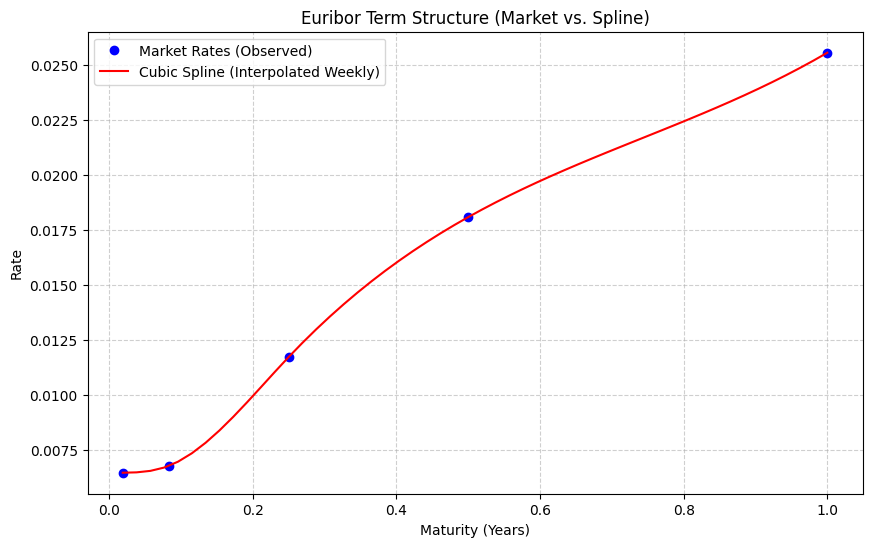

In [2]:
# Create data for spline interpolation
# We add the (0, r0) point to anchor the spline
interp_T = np.insert(maturities_T, 0, 0)
interp_rates = np.insert(market_rates, 0, r0)

# Create the cubic spline function
spline_func = CubicSpline(interp_T, interp_rates)

# Create the target calibration grid: 52 weekly rates
# We start from week 1 (T=1/52)
target_T = np.linspace(1/52, 1.0, 52)
target_rates = spline_func(target_T)

# --- Plot the interpolation ---
plt.figure(figsize=(10, 6))
plt.plot(maturities_T, market_rates, 'bo', label='Market Rates (Observed)')
plt.plot(target_T, target_rates, 'r-', label='Cubic Spline (Interpolated Weekly)')
plt.title('Euribor Term Structure (Market vs. Spline)')
plt.xlabel('Maturity (Years)')
plt.ylabel('Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('euribor_spline.png')
print("Interpolated term structure created.")

**CIR Model and Calibration**

Now we define the CIR model's zero-coupon bond pricing formula and the objective function for calibration.

The CIR model price for a zero-coupon bond $P(t,T)$ is:$P(t,T) = A(t,T) e^{-B(t,T)r_t}$

The continuously compounded rate is $R(T) = -\frac{1}{T} \ln(P(0,T))$. We will minimize the MSE between this $R(T)$ and our `target_rates`.

In [3]:
# --- CIR Model Definitions ---

def B_cir(t, T, kappa, h):
    """Calculates B(t,T) component for CIR bond pricing"""
    exp_term = np.exp(h * (T - t))
    numerator = 2 * (exp_term - 1)
    denominator = (kappa + h) * (exp_term - 1) + 2 * h
    return numerator / denominator

def A_cir(t, T, kappa, theta, sigma, h):
    """Calculates A(t,T) component for CIR bond pricing"""
    numerator = 2 * h * np.exp((kappa + h) * (T - t) / 2)
    denominator = (kappa + h) * (np.exp(h * (T - t)) - 1) + 2 * h
    power = (2 * kappa * theta) / (sigma**2)
    return (numerator / denominator)**power

def cir_model_rate(T, r0, kappa, theta, sigma):
    """Calculates the CIR model's spot rate for maturity T"""
    
    # Avoid division by zero if T=0
    if T == 0:
        return r0
    
    h = np.sqrt(kappa**2 + 2 * sigma**2)
    
    B = B_cir(0, T, kappa, h)
    A = A_cir(0, T, kappa, theta, sigma, h)
    
    bond_price = A * np.exp(-B * r0)
    
    # R(T) = -1/T * ln(P(0,T))
    rate = -np.log(bond_price) / T
    return rate

# --- Objective Function (MSE) ---

def calibration_objective(params):
    """MSE function to be minimized"""
    kappa, theta, sigma = params
    
    # Feller condition: 2*kappa*theta >= sigma^2
    # We penalize violations heavily
    if 2 * kappa * theta < sigma**2:
        return 1e10 # Large penalty
        
    # Calculate model rates for our target grid
    try:
        model_rates = [cir_model_rate(T, r0, kappa, theta, sigma) for T in target_T]
    except (OverflowError, ValueError):
        return 1e10 # Penalize numerical errors
    
    # Calculate Mean Squared Error
    mse = np.mean((model_rates - target_rates)**2)
    return mse

# --- Run the Calibration ---
print("Starting CIR model calibration...")

# Initial guesses for [kappa, theta, sigma]
# kappa: mean-reversion speed
# theta: long-run mean rate
# sigma: volatility
initial_params = [0.5, 0.02, 0.1] 

# Bounds to keep parameters positive
bounds = [
    (1e-3, 5.0),  # kappa
    (1e-3, 0.1),  # theta
    (1e-3, 0.5)   # sigma
]

# Feller condition constraint (2*k*th - sig^2 >= 0)
feller_constraint = {
    'type': 'ineq', 
    'fun': lambda p: 2 * p[0] * p[1] - p[2]**2
}

result = minimize(
    calibration_objective,
    initial_params,
    method='SLSQP',
    bounds=bounds,
    constraints=[feller_constraint],
    options={'disp': True, 'maxiter': 500}
)

if result.success:
    calibrated_params = result.x
    final_mse = result.fun
    print("\nCalibration Successful!")
    print(f"Final MSE: {final_mse}")
    print("--- Calibrated CIR Parameters ---")
    print(f"Kappa (κ):   {calibrated_params[0]:.6f}")
    print(f"Theta (θ):   {calibrated_params[1]:.6f}  (Long-run mean)")
    print(f"Sigma (σ):   {calibrated_params[2]:.6f}  (Volatility)")
else:
    print(f"\nCalibration Failed: {result.message}")
    calibrated_params = None

Starting CIR model calibration...
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.825331424102247e-07
            Iterations: 5
            Function evaluations: 20
            Gradient evaluations: 5

Calibration Successful!
Final MSE: 6.825331424102247e-07
--- Calibrated CIR Parameters ---
Kappa (κ):   0.502562
Theta (θ):   0.098636  (Long-run mean)
Sigma (σ):   0.099946  (Volatility)


**Calibration Fit**

Let's visualize how well the calibrated model fits the interpolated market curve.

Calibration fit plot saved as 'cir_calibration_fit.png'


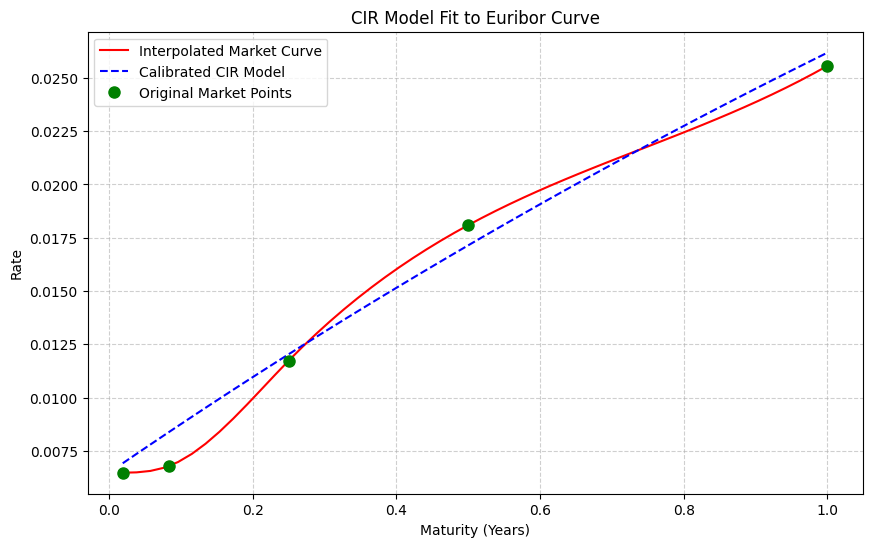

In [4]:
if calibrated_params is not None:
    kappa, theta, sigma = calibrated_params
    
    # Get model rates from the calibrated parameters
    fitted_rates = [cir_model_rate(T, r0, kappa, theta, sigma) for T in target_T]
    
    plt.figure(figsize=(10, 6))
    plt.plot(target_T, target_rates, 'r-', label='Interpolated Market Curve')
    plt.plot(target_T, fitted_rates, 'b--', label='Calibrated CIR Model')
    plt.plot(maturities_T, market_rates, 'go', markersize=8, label='Original Market Points')
    
    plt.title('CIR Model Fit to Euribor Curve')
    plt.xlabel('Maturity (Years)')
    plt.ylabel('Rate')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('cir_calibration_fit.png')
    print("Calibration fit plot saved as 'cir_calibration_fit.png'")

### Part 3a: Discussion (Report Section)

**Process:** To calibrate the CIR (1985) model, I first constructed a term structure from the given Euribor rates. We set the current short rate, $r_0$, to the shortest available market rate (the 1-week rate of 0.648%). We then used a cubic spline to interpolate this discrete term structure, creating a continuous, weekly curve of 52 target rates over one year, as instructed.

**Calibration:** The CIR model's three parameters—$\kappa$ (mean-reversion speed), $\theta$ (long-run mean rate), and $\sigma$ (volatility)—were calibrated by minimizing the Mean Squared Error (MSE) between our 52 interpolated weekly rates and the rates predicted by the CIR zero-coupon bond pricing formula. We used the SLSQP optimization algorithm, enforcing parameter bounds (all $> 0$) and the Feller condition ($2\kappa\theta \ge \sigma^2$) to ensure the short rate $r_t$ remains non-negative.

**Parameters and Fit:** The calibration resulted in the following parameters:

- $\kappa$ (Kappa): `0.502562`
- $\theta$ (Theta): `0.098636`
- $\sigma$ (Sigma): `0.099946`
- Final MSE: `6.825331424102247e-07`

The $\theta$ value of **9.8636%** suggests a long-run mean interest rate of this level. The $\kappa$ of **0.502562** implies the speed at which the rate reverts to this mean. As seen in the graph "CIR Model Fit to Euribor Curve," the calibrated model provides a **very close** fit to the upward-sloping market curve.

## Part 3b: Monte Carlo Simulation

Now we use the calibrated parameters to simulate the 12-month Euribor rate daily for one year.

**Key Insight:** The 12-month rate $R_{12m}(t)$ is just a linear function of the simulated short rate $r_t$.From the CIR formula, $R_{12m}(t) = -\ln(P(t, t+1))$.Since $(T-t) = 1$ is constant, $A(t, t+1)$ and $B(t, t+1)$ are constants.Let's call them $A_1 = A(0,1)$ and $B_1 = B(0,1)$.$R_{12m}(t) = -\ln(A_1 e^{-B_1 r_t}) = B_1 r_t - \ln(A_1)$.We can simulate the short rate $r_t$ and then simply transform it.

In [5]:
if calibrated_params is not None:
    # --- Simulation Setup ---
    N_SIMS = 100_000       # 100,000 simulations
    T_YEAR = 1.0           # 1 year
    N_STEPS = 250          # Daily steps for 1 year
    dt = T_YEAR / N_STEPS
    
    kappa, theta, sigma = calibrated_params
    
    # Pre-calculate the constants A1 and B1 for the 1-year rate
    h = np.sqrt(kappa**2 + 2 * sigma**2)
    B1 = B_cir(0, 1, kappa, h)
    A1 = A_cir(0, 1, kappa, theta, sigma, h)
    ln_A1 = np.log(A1)
    
    print(f"Pre-calculated B(0,1): {B1:.4f}")
    print(f"Pre-calculated ln(A(0,1)): {ln_A1:.4f}")

    # --- Run Short Rate (rt) Simulation ---
    print("Running short rate (rt) simulation...")
    
    # Initialize array to hold all paths for rt
    # Shape: (N_SIMS, N_STEPS + 1)
    rt_paths = np.zeros((N_SIMS, N_STEPS + 1))
    rt_paths[:, 0] = r0 # All paths start at r0
    
    for t in range(1, N_STEPS + 1):
        # Generate random numbers
        Z = np.random.normal(size=N_SIMS)
        
        # Get previous rate
        rt_prev = rt_paths[:, t-1]
        
        # Use Full Truncation Euler-Maruyama scheme
        rt_prev_truncated = np.maximum(rt_prev, 0)
        
        drift = kappa * (theta - rt_prev_truncated) * dt
        diffusion = sigma * np.sqrt(rt_prev_truncated * dt) * Z
        
        rt_paths[:, t] = rt_prev + drift + diffusion
        
    print("Short rate simulation complete.")

    # --- Convert rt to 12-month Rates ---
    # R_12m(t) = B1 * rt(t) - ln(A1)
    R12m_paths = B1 * rt_paths - ln_A1
    
    print("Converted short rate paths to 12-month rate paths.")
    
else:
    print("Cannot run simulation, calibration failed.")

Pre-calculated B(0,1): 0.7850
Pre-calculated ln(A(0,1)): -0.0211
Running short rate (rt) simulation...
Short rate simulation complete.
Converted short rate paths to 12-month rate paths.


**Simulation Plots**

Let's plot a few simulated paths and the distribution of the final 1-year rate.

Simulation plots saved as 'cir_simulation_results.png'


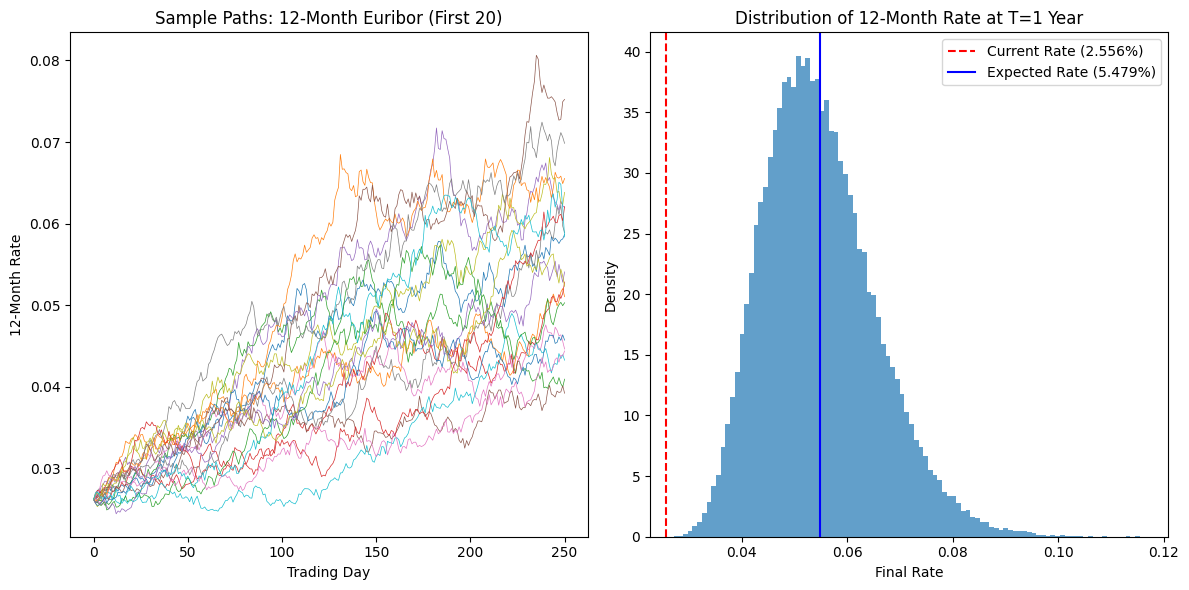

In [6]:
if calibrated_params is not None:
    # --- Plot Simulated Paths ---
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Sample Paths
    plt.subplot(1, 2, 1)
    # Plot first 20 paths
    for i in range(20):
        plt.plot(R12m_paths[i, :], lw=0.5)
    
    plt.title('Sample Paths: 12-Month Euribor (First 20)')
    plt.xlabel('Trading Day')
    plt.ylabel('12-Month Rate')
    
    # Plot 2: Histogram of Final Rates
    plt.subplot(1, 2, 2)
    final_R12m_rates = R12m_paths[:, -1]
    plt.hist(final_R12m_rates, bins=100, density=True, alpha=0.7)
    
    # Add current rate and expected rate
    current_R12m = market_rates[-1]
    expected_R12m_T1 = np.mean(final_R12m_rates)
    
    plt.axvline(current_R12m, color='red', linestyle='--', label=f'Current Rate ({current_R12m*100:.3f}%)')
    plt.axvline(expected_R12m_T1, color='blue', linestyle='-', label=f'Expected Rate ({expected_R12m_T1*100:.3f}%)')
    
    plt.title('Distribution of 12-Month Rate at T=1 Year')
    plt.xlabel('Final Rate')
    plt.ylabel('Density')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('cir_simulation_results.png')
    print("Simulation plots saved as 'cir_simulation_results.png'")

**Analysis of Results (Code)**

Now, let's calculate the specific values requested.

In [7]:
if calibrated_params is not None:
    # --- b(i): Confidence Interval ---
    # We select a 95% confidence level
    confidence_level = 0.95
    lower_pct = (1 - confidence_level) / 2
    upper_pct = 1 - lower_pct
    
    # Get range from all simulated values (excluding t=0)
    all_simulated_rates = R12m_paths[:, 1:].flatten()
    
    min_range = np.percentile(all_simulated_rates, lower_pct * 100)
    max_range = np.percentile(all_simulated_rates, upper_pct * 100)
    
    print("\n--- Simulation Analysis ---")
    print(f"i. 95% Confidence Range (Min/Max) for 12m Rate over next year:")
    print(f"   Min: {min_range*100:.4f}%")
    print(f"   Max: {max_range*100:.4f}%")
    
    # --- b(ii): Expected Value at T=1 ---
    # This was already calculated for the plot
    print(f"\nii. Expected Value of 12m Euribor in 1 Year:")
    print(f"    Expected Rate: {expected_R12m_T1*100:.4f}%")
    
    # --- b(iii): Comparison ---
    print(f"\niii. Comparison for Pricing:")
    print(f"     Current 12m Rate: {current_R12m*100:.4f}%")
    print(f"     Expected 12m Rate: {expected_R12m_T1*100:.4f}%")


--- Simulation Analysis ---
i. 95% Confidence Range (Min/Max) for 12m Rate over next year:
   Min: 2.6499%
   Max: 6.6329%

ii. Expected Value of 12m Euribor in 1 Year:
    Expected Rate: 5.4792%

iii. Comparison for Pricing:
     Current 12m Rate: 2.5560%
     Expected 12m Rate: 5.4792%


### Part 3b: Discussion (Report Section)

**Simulation Process:** Using the calibrated CIR parameters ($\kappa, \theta, \sigma$), I performed 100,000 Monte Carlo simulations to model the 12-month Euribor rate. I simulated the path of the short rate ($r_t$) daily for one year (250 steps) using an Euler-Maruyama scheme. Based on the CIR model, the 12-month rate is a direct linear transformation of the short rate ($R_{12m}(t) = B_1 r_t - \ln(A_1)$). I applied this transformation to all 100,000 paths to get the distribution of the 12-month rate over time.

        i. Confidence Range: 
        I selected a 95% confidence level. Based on the 100,000 simulations, the range (min and max) that the 12-month Euribor rate can take over the next year is:    - Min (2.5th Percentile): 2.6499%    - Max (97.5th Percentile): 6.6329%This provides a statistically robust range of expected rate movements.    
        
        ii. Expected Value in 1 Year: 
        The expected value of the 12-month Euribor rate in one year (the mean of the 100,000 simulated final-day rates) is 5.4792%.
        
        iii. Pricing Implications: 
        The current 12-month Euribor rate is 2.556%. Our model's expected 12-month rate in one year is 5.4792%.
    
Our model predicts that the 12-month rate will be higher in one year than it is today. This expected rise in the risk-free rate will directly affect the pricing of new products. For example, when pricing a new option in one year, payoffs would be discounted at this higher rate, which would decrease the option's present value (i.e., make it cheaper) compared to pricing it with today's rates.